# FED3 PR1 analysis
<br>
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQqe_1a1j1bQaqhOxq0VvukPqfolLRUqOdl-g&s" width="200" />

Updated: 01.12.25  
Version 1.1.0
Authored by Chantelle Murrell and Sebastian Alves



In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
#!pip install pingouin
import sys
sys.path.insert(0, "src")           # relative to the project root where the notebook runs
from fedlib.extracted import fed3bandit_extracted, fed3_loading, fed3_fedframe
from fedlib.fedcore import core
from fedlib.fedassays import fedpr1


# Import other libraries (will have to kick out to top level)
import pandas as pd
import os
import zipfile
from pathlib import Path
from contextlib import ExitStack
import tempfile
import warnings

# for reloading packages
import importlib

c:\Users\william.b\Documents\GitHub\fedlib\src\fedlib\extracted\fed3bandit_extracted.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# ============================ Declare Paths ========================== # 
# PR1 FMR1
ROOT_PATH = Path(r"C:\Users\william.b\Box\Kravitz Lab Box Drive\William\5_fed3_pipeline\TESTDIRDATA\FMR1\pr1")

# define the directory for the L1 zipped data
L1_PATH = Path(ROOT_PATH, "FMR1_007_PR1_L1.zip")

# define the path for the key file
# the key file should always be a xlsx
KEY_PATH = Path(ROOT_PATH, "FMR1_007_Key.xlsx")

In [4]:
#@title Upload files
# reload packages
importlib.reload(core)

# fed3 warns on duplicate timestamps, but for FED data this is expected
# and not meaningful — suppress it globally rather than logging per-file
warnings.filterwarnings(
    "ignore",
    message="Index has duplicate values.*",
    category=RuntimeWarning,
)

# ========================== Call functions ============================ #
# ------ Ingest data ------ #
# call to lkoad lists and ingest the data from the l1 folder
fed_list, loaded_files, session_types = core.ingest_l1(L1_PATH)

# ------ Create Meta Data Key ------ #
# upload key file
key_df, msg = core._read_key_from_upload(KEY_PATH)

# build key dataframe
key_df2 = core.build_or_rematch_key_df(loaded_files, session_types, key_df, msg_hint = f"Key status: {msg}")


==> Beginning Ingest
  [ok] Ingest Complete - Loaded 46 files. Session types captured for all.
==> Reading in key file
  [ok] Done - Key loaded
==> Building key dataframe
  [ok] Key status: Key loaded from upload (FMR1_007_Key.xlsx). 'Mouse_ID' found.
  [ok] Merged key columns into Key_Df (46 rows, 27 cols).


In [5]:
importlib.reload(fedpr1)

# Create individual PR1 plots
saved_paths_indv = fedpr1.pr1_indv_plots(fed_list, key_df2, ROOT_PATH)



==> Creating individual PR1 Plots
  [ok] saved FMR1_007_207_62_indvPR1
  [ok] saved FMR1_007_220_7_indvPR1
  [ok] saved FMR1_007_212_88_indvPR1
  [ok] saved FMR1_007_212_89_indvPR1
  [ok] saved FMR1_007_211_82_indvPR1
  [ok] saved FMR1_007_211_84_indvPR1
  [ok] saved FMR1_007_217_58_indvPR1
  [ok] saved FMR1_007_216_73_indvPR1
  [ok] saved FMR1_007_210_79_indvPR1
  [ok] saved FMR1_007_221_47_indvPR1
  [ok] saved FMR1_007_221_51_indvPR1
  [ok] saved FMR1_007_221_50_indvPR1
  [ok] saved FMR1_007_213_39_indvPR1
  [ok] saved FMR1_007_214_98_indvPR1
  [ok] saved FMR1_007_218_77_indvPR1
  [ok] saved FMR1_007_215_1_indvPR1
  [ok] saved FMR1_007_214_94_indvPR1
  [ok] saved FMR1_007_220_11_indvPR1
  [ok] saved FMR1_007_219_23_indvPR1
  [ok] saved FMR1_007_215_5_indvPR1
  [ok] saved FMR1_007_222_18_indvPR1
  [ok] saved FMR1_007_219_29_indvPR1
  [ok] saved FMR1_007_217_55_indvPR1
  [ok] saved FMR1_007_219_27_indvPR1
  [ok] saved FMR1_007_217_52_indvPR1
  [ok] saved FMR1_007_221_48_indvPR1
  [ok] 

In [6]:
importlib.reload(core)
importlib.reload(fedpr1)



# Clean PR1 metadata
meta_cols, md = core.build_metakey(key_df2, assay = "bandit")

# Find ID columns
id_col, other_id = core.pick_match_method(md)

# compute PR metrics
pm = fedpr1.compute_pr_metrics(fed_list, md)

pm_md = core.attach_meta(pm, md, id_col)

# Build the l3
pm_l3 = core.output_l3(pm_md, id_col, other_id, meta_cols, ROOT_PATH, assay = "pr1", )



100%|██████████| 46/46 [00:00<00:00, 549.26it/s]
  [ok] First set of metrics calculated
  [preview] preview — 46 rows x 10 cols
                      count      mean       std       min       25%       50%       75%       max
    Left_Poke          46.0  3346.043  1265.475   886.000  2515.000  3288.500  3926.250  6726.000
    Right_Poke         46.0   617.630   228.009   201.000   462.750   623.500   810.750  1057.000
    Total_Pokes        46.0  3963.674  1431.173  1129.000  3115.000  3851.000  4814.250  7673.000
    Accuracy           46.0    83.935     4.223    75.969    81.030    84.604    86.890    93.408
    PokesPerPellet     46.0    16.897     6.095     6.801    13.078    16.286    19.604    39.148
    MedianBreakPoint   46.0    10.239     9.189     4.000     6.000     8.000     9.375    60.000
    MaxBreakPoint      46.0    47.978    15.244    18.000    38.250    45.000    55.000    87.000
    Numberofblocks     46.0    17.261     6.104     3.000    13.250    18.000    21.750 

In [7]:
importlib.reload(core)
importlib.reload(fedpr1)

### Build groupings
mapped_df = core.build_group_selections(md)

### attach the grouping dataframe to the metrics
pm_grps_df = core.merge_group_selections(pm_md, mapped_df)



==> Building group selection dataframe
  [ok] X-axis grouping (hierarchy): ['Genotype']
  [ok] Total unique files (X map): 46
  [table] table — 4 rows x 1 cols
           UniqueFiles
    Group             
    WT              16
    HET             12
    HOM             11
    HEMI             7
  [ok] Hue grouping: ['Sex']
  [ok] Total unique files (Hue map): 46
  [table] table — 2 rows x 1 cols
           UniqueFiles
    Group             
    F               30
    M               16
  [ok] Grouping dataframe built
==> Merging group df and metric df
  [ok] Group and Metric dataframe merged


In [8]:
importlib.reload(core)
importlib.reload(fedpr1)

# Plot PR
### Melt the metric dataframe to long format
pm_long = core.melt_metric(pm_grps_df, assay = "pr1")

### Create variables to control aesthetics
x_checks, x_colors, ordered_x = core.define_aesthetics(pm_long)

# Actually create the bar plots 
barplot_paths = core._run_plots(pm_long, x_checks, x_colors, ordered_x, ROOT_PATH)





==> Melting L3 to long format
  [ok] Metric dataframe Melted
==> Defining Aesthetics for Plotting
  [ok] Aesthetics defined - x_checks: {'WT': Checkbox(value=True, description='WT', indent=False, layout=Layout(width='260px')), 'HEMI': Checkbox(value=True, description='HEMI', indent=False, layout=Layout(width='260px')), 'HET': Checkbox(value=True, description='HET', indent=False, layout=Layout(width='260px')), 'HOM': Checkbox(value=True, description='HOM', indent=False, layout=Layout(width='260px'))}
  [ok] Aesthetics defined - x_colors: {'WT': Text(value='#7ACAFF', layout=Layout(width='120px')), 'HEMI': Text(value='#FFB193', layout=Layout(width='120px')), 'HET': Text(value='#9BDF94', layout=Layout(width='120px')), 'HOM': Text(value='#D2ACD3', layout=Layout(width='120px'))}
  [ok] Aesthetics defined - ordered_x: ['WT', 'HEMI', 'HET', 'HOM']
==> Creating Metric Plots
  [ok] Showing X groups: ['WT', 'HEMI', 'HET', 'HOM']  |  reference for stars: WT
c:\Users\william.b\AppData\Local\anacond

  [warn] Stats table emtpy


[HEMI]
  alpha_mean = 15.4416, beta_mean = 2.2740
  Q_meanparams(P = alpha_mean): P = 15.4416, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 15.4481, Q = 45.7867

[HET]
  alpha_mean = 11.3001, beta_mean = 1.8976
  Q_meanparams(P = alpha_mean): P = 11.3001, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 11.2246, Q = 46.6810

[HOM]
  alpha_mean = 8.2616, beta_mean = 1.9932
  Q_meanparams(P = alpha_mean): P = 8.2616, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 8.1559, Q = 47.7099

[WT]
  alpha_mean = 9.1880, beta_mean = 1.8747
  Q_meanparams(P = alpha_mean): P = 9.1880, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 9.3522, Q = 48.2345



,Group,N_mice,alpha_mean,alpha_sem,beta_mean,beta_sem
0,HEMI,6,15.442,3.565,2.274,0.283
1,HET,12,11.300,1.442,1.898,0.072
2,HOM,11,8.262,0.553,1.993,0.192
3,WT,16,9.188,0.567,1.875,0.117


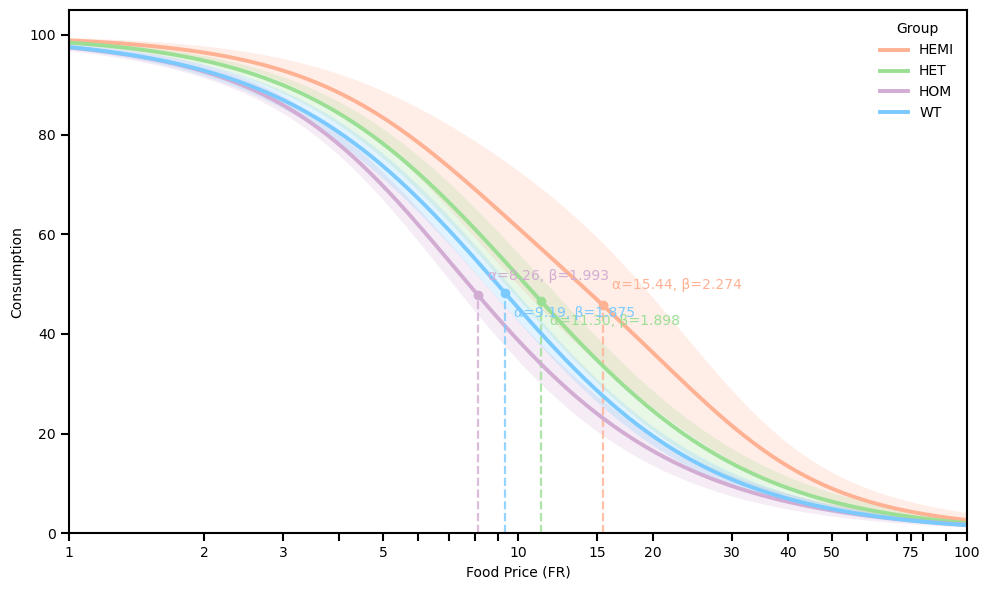

In [9]:
### grouped demand curves
importlib.reload(fedpr1)

fig, stats = fedpr1.plot_group_mean_demand_with_params(mapped_df, pm_grps_df, md, x_colors)

In [12]:
### assemble L4
# output L4
importlib.reload(fedpr1)
importlib.reload(core)
fedpr1.assemble_pr_l4(pm_long, x_colors, ordered_x, pm_md, ROOT_PATH, fed_list=fed_list, metadata_df=key_df2, bandittype = "100")

==> Assembling PR1 L4 composite figure
  [ok] L4 example mouse -> FMR1_007_307_42
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covaria

WindowsPath('C:/Users/william.b/Box/Kravitz Lab Box Drive/William/5_fed3_pipeline/TESTDIRDATA/FMR1/pr1/L4/FMR1_PR_L4.svg')

==> Beginning Ingest
  [ok] Ingest Complete - Loaded 39 files. Session types captured for all.
==> Reading in key file
  [ok] Done - Key loaded
==> Building key dataframe
  [ok] Key status: Key loaded from upload (MYT1L_001_Key.xlsx). 'Mouse_ID' found.
  [ok] Merged key columns into Key_Df (39 rows, 25 cols).
==> Creating individual PR1 Plots
  [ok] saved MYT1L_001_9_14_indvPR1
  [ok] saved MYT1L_001_5_24_indvPR1
  [ok] saved MYT1L_001_5_28_indvPR1
  [ok] saved MYT1L_001_2_5_indvPR1
  [ok] saved MYT1L_001_2_8_indvPR1
  [ok] saved MYT1L_001_9_12_indvPR1
  [ok] saved MYT1L_001_12_46_indvPR1
  [ok] saved MYT1L_001_12_51_indvPR1
  [ok] saved MYT1L_001_1_1_indvPR1
  [ok] saved MYT1L_001_5_23_indvPR1
  [ok] saved MYT1L_001_5_27_indvPR1
  [ok] saved MYT1L_001_1_4_indvPR1
  [ok] saved MYT1L_001_2_6_indvPR1
  [ok] saved MYT1L_001_9_11_indvPR1
  [ok] saved MYT1L_001_7_32_indvPR1
  [ok] saved MYT1L_001_8_41_indvPR1
  [ok] saved MYT1L_001_10_42_indvPR1
  [ok] saved MYT1L_001_12_48_indvPR1
  [ok] s

[HET]
  alpha_mean = 10.3860, beta_mean = 2.0082
  Q_meanparams(P = alpha_mean): P = 10.3860, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 10.2153, Q = 47.5974

[WT]
  alpha_mean = 12.1804, beta_mean = 1.9763
  Q_meanparams(P = alpha_mean): P = 12.1804, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 12.2148, Q = 47.2681



,Group,N_mice,alpha_mean,alpha_sem,beta_mean,beta_sem
0,HET,19,10.386,0.953,2.008,0.085
1,WT,20,12.180,0.830,1.976,0.094


==> Assembling PR1 L4 composite figure
  [ok] L4 example mouse -> MYT1L_001_12_47
  [ok] PR1 L4 composite saved -> C:\Users\william.b\Box\Kravitz Lab Box Drive\William\5_fed3_pipeline\TESTDIRDATA\MYT1L\pr1\L4\MYT1L_PR_L4.svg
==> Beginning Ingest
  [ok] Ingest Complete - Loaded 46 files. Session types captured for all.
==> Reading in key file
  [ok] Done - Key loaded
==> Building key dataframe
  [ok] Key status: Key loaded from upload (FMR1_007_Key.xlsx). 'Mouse_ID' found.
  [ok] Merged key columns into Key_Df (46 rows, 27 cols).
==> Creating individual PR1 Plots
  [ok] saved FMR1_007_207_62_indvPR1
  [ok] saved FMR1_007_220_7_indvPR1
  [ok] saved FMR1_007_212_88_indvPR1
  [ok] saved FMR1_007_212_89_indvPR1
  [ok] saved FMR1_007_211_82_indvPR1
  [ok] saved FMR1_007_211_84_indvPR1
  [ok] saved FMR1_007_217_58_indvPR1
  [ok] saved FMR1_007_216_73_indvPR1
  [ok] saved FMR1_007_210_79_indvPR1
  [ok] saved FMR1_007_221_47_indvPR1
  [ok] saved FMR1_007_221_51_indvPR1
  [ok] saved FMR1_007_221

[HEMI]
  alpha_mean = 15.4416, beta_mean = 2.2740
  Q_meanparams(P = alpha_mean): P = 15.4416, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 15.4481, Q = 45.7867

[HET]
  alpha_mean = 11.3001, beta_mean = 1.8976
  Q_meanparams(P = alpha_mean): P = 11.3001, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 11.2246, Q = 46.6810

[HOM]
  alpha_mean = 8.2616, beta_mean = 1.9932
  Q_meanparams(P = alpha_mean): P = 8.2616, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 8.1559, Q = 47.7099

[WT]
  alpha_mean = 9.1880, beta_mean = 1.8747
  Q_meanparams(P = alpha_mean): P = 9.1880, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 9.3522, Q = 48.2345



,Group,N_mice,alpha_mean,alpha_sem,beta_mean,beta_sem
0,HEMI,6,15.442,3.565,2.274,0.283
1,HET,12,11.300,1.442,1.898,0.072
2,HOM,11,8.262,0.553,1.993,0.192
3,WT,16,9.188,0.567,1.875,0.117


==> Assembling PR1 L4 composite figure
  [ok] L4 example mouse -> FMR1_007_307_42
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covaria

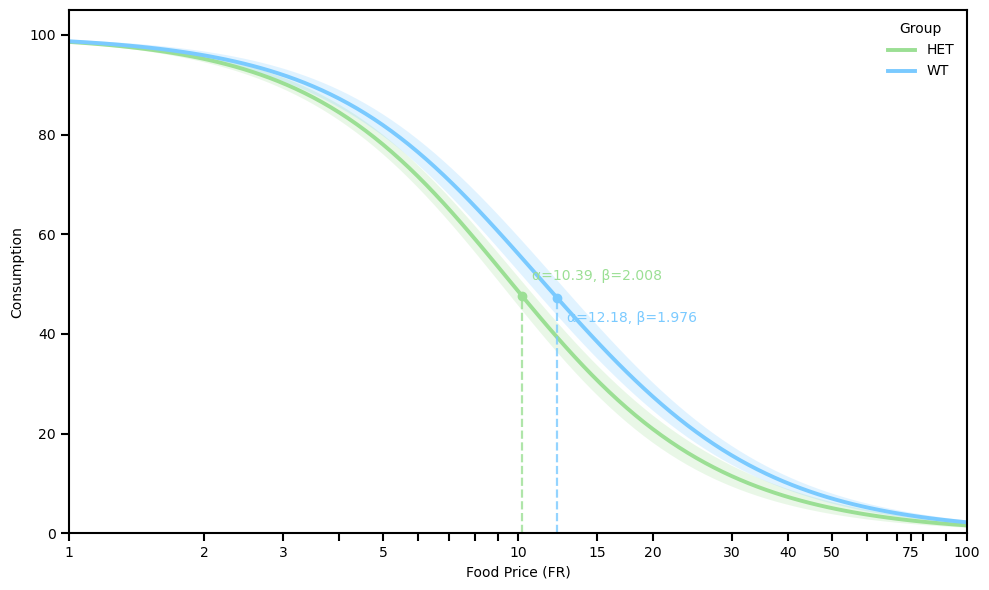

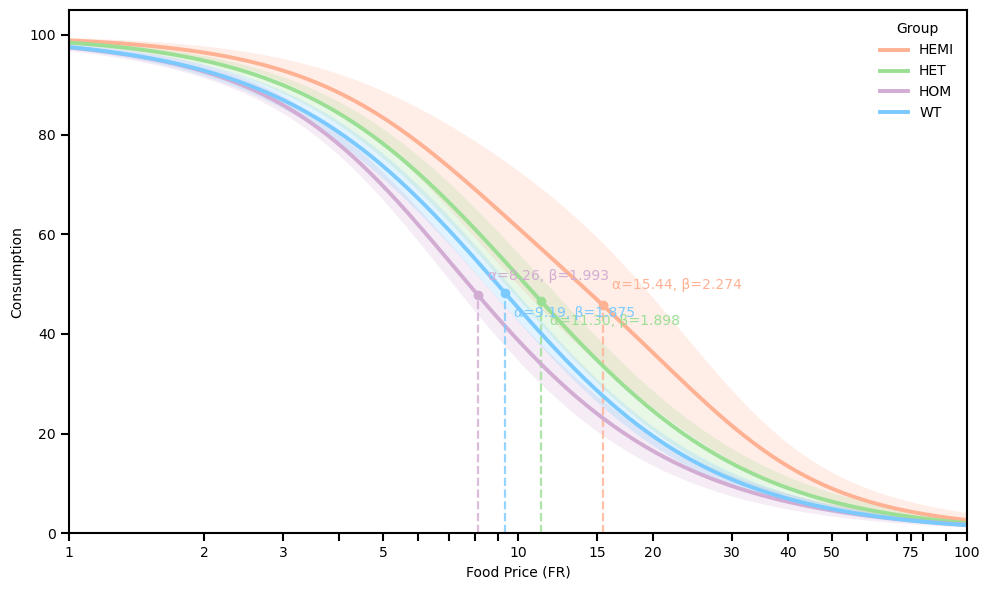

In [50]:
# call the pipeline
importlib.reload(fedpr1)
importlib.reload(core)

# Myt1l
root = Path(r"C:\Users\william.b\Box\Kravitz Lab Box Drive\William\5_fed3_pipeline\TESTDIRDATA\MYT1L\pr1")
res = fedpr1.run_pr_l1_l4(root / "MYT1L_001_PR1_L1.zip",
                          root / "MYT1L_001_Key.xlsx", root)

# FMRI
root = Path(r"C:\Users\william.b\Box\Kravitz Lab Box Drive\William\5_fed3_pipeline\TESTDIRDATA\FMR1\pr1")
res = fedpr1.run_pr_l1_l4(root / "FMR1_007_PR1_L1.zip",
                          root / "FMR1_007_Key.xlsx", root)

In [ ]:
# @title Analyse PR metrics




# --------------------
# 3) Compute PR metrics (file-level)
# --------------------
rows = []
for idx, c_df in enumerate(_tqdm(feds, desc="Computing PR metrics")):
    file_name = _basename(getattr(c_df, "name", f"File_{idx}"))

    pellets = _count_events(c_df, "Pellet")
    left    = _count_events(c_df, "Left")
    right   = _count_events(c_df, "Right")
    total   = left + right

    acc = (left / total * 100.0) if total > 0 else np.nan
    ppp = (total / pellets) if pellets > 0 else np.nan

    med_bp, max_bp, runs = breakpoint_and_runs(c_df)
    daily = _estimate_daily_pellets(c_df)

    rows.append({
        "filename": file_name,
        "Left_Poke": left,
        "Right_Poke": right,
        "Total_Pokes": total,
        "Accuracy": acc,
        "PokesPerPellet": ppp,
        "MedianBreakPoint": med_bp,
        "MaxBreakPoint": max_bp,
        "Numberofblocks": runs,
        "Daily_Pellets": daily,   # use consistent name (recommended)
    })

PRmetrics = pd.DataFrame(rows)
if PRmetrics.empty:
    display(HTML("<b style='color:#b00'>No files to analyze.</b>"))
    raise SystemExit

# --------------------
# 4) Demand fits (mouse-level) — keep your logic, but ensure Mouse_ID exists first
#     We attach Mouse_ID from md now so demand fitting can group by mouse.
# --------------------
if "filename" in md.columns and "Mouse_ID" in md.columns:
    mouse_map = md.dropna(subset=["filename"]).drop_duplicates("filename").set_index("filename")["Mouse_ID"]
    PRmetrics["Mouse_ID"] = PRmetrics["filename"].map(mouse_map)
else:
    PRmetrics["Mouse_ID"] = np.nan

# substring fallback if still missing
if PRmetrics["Mouse_ID"].isna().any() and ("Mouse_ID" in md.columns):
    known_ids = md["Mouse_ID"].dropna().unique().tolist()
    for i, r in PRmetrics.loc[PRmetrics["Mouse_ID"].isna()].iterrows():
        base = _file_base_lower(r["filename"])
        hits = [mid for mid in known_ids if str(mid).lower() in base]
        if len(hits) == 1:
            PRmetrics.at[i, "Mouse_ID"] = hits[0]
        elif len(hits) > 1:
            longest = max(len(str(h)) for h in hits)
            best = [h for h in hits if len(str(h)) == longest]
            if len(best) == 1:
                PRmetrics.at[i, "Mouse_ID"] = best[0]

# build filename->df map
file_names = [_basename(getattr(df, "name", f"File_{i}")) for i, df in enumerate(feds)]
file_to_df = dict(zip(file_names, feds))

MIN_RUNS_PER_MOUSE = 10
runs_per_mouse = (
    PRmetrics.dropna(subset=["Mouse_ID"])
    .groupby("Mouse_ID")["Numberofblocks"]
    .sum()
    .to_dict()
)
keep_mice = {m for m, r in runs_per_mouse.items() if r >= MIN_RUNS_PER_MOUSE}
for m, r in runs_per_mouse.items():
    if m not in keep_mice:
        print(f"[{m}] skipped: only {r} blocks (< {MIN_RUNS_PER_MOUSE}).")

raw_rows = []
for fn, df in file_to_df.items():
    mouse = PRmetrics.loc[PRmetrics["filename"] == fn, "Mouse_ID"]
    mouse = mouse.iloc[0] if len(mouse) else None
    if (mouse is None) or (mouse not in keep_mice):
        continue
    if {"Event", "Block_Pellet_Count"} - set(df.columns):
        print(f"[{mouse}] file {fn} missing Event/BPC columns; skipped.")
        continue

    pellets_df = df[df["Event"].astype(str) == "Pellet"].copy()
    if pellets_df.empty:
        print(f"[{mouse}] file {fn} has 0 pellet rows; skipped.")
        continue

    bpc = pd.to_numeric(pellets_df["Block_Pellet_Count"], errors="coerce")
    counts = (
        pellets_df.assign(Block_Pellet_Count=bpc)
        .dropna(subset=["Block_Pellet_Count"])
        .groupby("Block_Pellet_Count")
        .size()
    )
    if counts.empty:
        print(f"[{mouse}] file {fn} produced no valid price bins; skipped.")
        continue

    for price, cnt in counts.items():
        raw_rows.append({"Mouse_ID": mouse, "PricePaid": int(price), "PelletCount": int(cnt)})

demand_raw_df = pd.DataFrame(raw_rows)

if demand_raw_df.empty:
    demand_metrics = pd.DataFrame(columns=[
        "Mouse_ID", "Demand_Q0_raw", "Demand_alpha_raw", "Demand_beta_raw",
        "Demand_alpha_FR", "Demand_beta_FR",
    ])
else:
    demand_mouse = (demand_raw_df
                    .groupby(["Mouse_ID", "PricePaid"], as_index=False)["PelletCount"]
                    .sum())

    def _baseline_B(sub):
        if sub.empty:
            return np.nan
        mprice = sub["PricePaid"].min()
        return sub.loc[sub["PricePaid"] == mprice, "PelletCount"].mean()

    B = (demand_mouse.groupby("Mouse_ID")
         .apply(_baseline_B).rename("B").reset_index())
    B["q"] = 100.0 / B["B"]

    normalized = (
        demand_mouse
        .merge(B[["Mouse_ID", "q"]], on="Mouse_ID", how="left")
        .assign(P_FR=lambda d: d["PricePaid"],
                Q_norm=lambda d: d["PelletCount"] * d["q"])
    )

    def loglog3(P, Q0, a, b):
        return Q0 / (1.0 + (P / a) ** b)

    def loglogN(P, a, b):
        return 100.0 / (1.0 + (P / a) ** b)

    raw_fit_rows = []
    for mouse, sub in demand_mouse.groupby("Mouse_ID"):
        P = sub["PricePaid"].to_numpy(float)
        Q = sub["PelletCount"].to_numpy(float)
        if np.unique(P).size < 3:
            print(f"[{mouse}] demand fit skipped (raw): need ≥3 unique FR levels.")
            continue
        try:
            popt, _ = curve_fit(
                loglog3, P, Q,
                p0=[Q.max(), float(np.median(P)), 2.0],
                bounds=([1e-6, 1e-6, 1e-3], [np.inf, np.inf, 50.0]),
                maxfev=20000
            )
            raw_fit_rows.append({
                "Mouse_ID": mouse,
                "Demand_Q0_raw": float(popt[0]),
                "Demand_alpha_raw": float(popt[1]),
                "Demand_beta_raw": float(popt[2]),
            })
        except Exception as e:
            print(f"[{mouse}] demand curve fit failed (raw): {e}")
    demand_fit_raw = pd.DataFrame(raw_fit_rows)

    fr_fit_rows = []
    for mouse, sub in normalized.groupby("Mouse_ID"):
        P = sub["P_FR"].to_numpy(float)
        Q = sub["Q_norm"].to_numpy(float)
        if np.unique(P).size < 3:
            print(f"[{mouse}] demand fit skipped (norm-Q): need ≥3 unique FR levels.")
            continue
        try:
            popt, _ = curve_fit(
                loglogN, P, Q,
                p0=[float(np.median(P)), 2.0],
                bounds=([1e-6, 1e-3], [np.inf, 50.0]),
                maxfev=20000
            )
            fr_fit_rows.append({
                "Mouse_ID": mouse,
                "Demand_alpha_FR": float(popt[0]),
                "Demand_beta_FR": float(popt[1]),
            })
        except Exception as e:
            print(f"[{mouse}] demand curve fit failed (norm-Q): {e}")
    demand_fit_fr = pd.DataFrame(fr_fit_rows)

    demand_metrics = demand_fit_raw.merge(demand_fit_fr, on="Mouse_ID", how="outer")

# merge demand into PRmetrics (Mouse-level)
PRmetrics = PRmetrics.merge(demand_metrics, on="Mouse_ID", how="left")

# --------------------
# 5) Attach metadata robustly (Bandit-style merge)
# --------------------
pm = PRmetrics.copy()

# If md has filename<->Mouse_ID, map Mouse_ID from filename (already done), but keep Bandit pattern
if "filename" in md.columns and "Mouse_ID" in md.columns and pm["Mouse_ID"].isna().any():
    mouse_map = md.dropna(subset=["filename"]).drop_duplicates("filename").set_index("filename")["Mouse_ID"]
    pm["Mouse_ID"] = pm["filename"].map(mouse_map)

# Merge metadata on best available key
if (id_col == "Mouse_ID") and ("Mouse_ID" in pm.columns) and ("Mouse_ID" in md.columns) and pm["Mouse_ID"].notna().any():
    md_unique = md.drop_duplicates(subset=["Mouse_ID"], keep="first")
    pm = pm.merge(md_unique, on="Mouse_ID", how="left", suffixes=("", "_md"))
else:
    if "filename" not in md.columns:
        raise ValueError("metadata_df has no 'filename' column, but filename is needed for this mode.")
    md_unique = md.drop_duplicates(subset=["filename"], keep="first")
    pm = pm.merge(md_unique, on="filename", how="left", suffixes=("", "_md"))

PRmetrics_merged = pm.copy()

# --------------------
# 6) Session-type suffixing (Bandit-style)
# --------------------
metric_cols = [
    "Left_Poke", "Right_Poke", "Total_Pokes", "Accuracy", "PokesPerPellet",
    "MedianBreakPoint", "Numberofblocks", "Daily_Pellets",
    "Demand_Q0_raw", "Demand_alpha_raw", "Demand_beta_raw",
    "Demand_alpha_FR", "Demand_beta_FR",
]
metric_cols = [c for c in metric_cols if c in PRmetrics_merged.columns]

bm = PRmetrics_merged.copy()

if "Session_type" in bm.columns:
    session_series = bm["Session_type"].astype(str).str.strip()
else:
    sess_map = {
        _basename(getattr(feds[i], "name", f"File_{i}")):
        (getattr(feds[i], "attrs", {}).get("Session_type") or "Unknown")
        for i in range(len(feds))
    }
    session_series = bm["filename"].map(sess_map).fillna("Unknown").astype(str)

session_series = session_series.str.replace(r"\s+", "_", regex=True)
bm["_Session_type_for_csv"] = session_series

def with_session_suffix_for_csv(df, metrics=metric_cols, session_col="_Session_type_for_csv"):
    df = df.copy()
    for m in metrics:
        if m not in df.columns:
            continue
        for sess in df[session_col].dropna().unique():
            mask = df[session_col] == sess
            col_name = f"{m}_{sess}"
            if col_name not in df.columns:
                df[col_name] = np.nan
            df.loc[mask, col_name] = df.loc[mask, m]
        df.drop(columns=[m], inplace=True)
    return df.drop(columns=[session_col])

PRmetrics_csv = with_session_suffix_for_csv(bm)

# --------------------
# 7) Final export columns (Bandit-style): [id_col] + wanted7 + suffixed metrics only
# --------------------
def _metric_match(col: str) -> bool:
    return any(col.startswith(base + "_") for base in metric_cols)

metric_keep = [c for c in PRmetrics_csv.columns if _metric_match(c)]
if not metric_keep:
    raise RuntimeError("No session-suffixed metric columns matched; check 'metric_cols'.")

meta_keep = [c for c in wanted7 if c in PRmetrics_csv.columns]

drop_cols = []
if other_id in PRmetrics_csv.columns:
    drop_cols.append(other_id)
for c in ["File", "FileIndex"]:
    if c in PRmetrics_csv.columns:
        drop_cols.append(c)

PRmetrics_csv = PRmetrics_csv.drop(columns=drop_cols, errors="ignore")

cols_out = [id_col] + meta_keep + metric_keep
cols_out = [c for c in cols_out if c in PRmetrics_csv.columns]
PRmetrics_csv = PRmetrics_csv.loc[:, cols_out].copy()

# --------------------
# 8) Save & present (same naming scheme as Bandit)
# --------------------
example = PRmetrics_merged.iloc[0]

strain_name = str(example.get("Gene", example.get("Strain", "PR"))).replace(" ", "_")
strain_num_raw = example.get("Gene_ID", example.get("Strain_ID", "NA"))
try:
    strain_num = f"{int(strain_num_raw):03d}"
except Exception:
    strain_num = str(strain_num_raw).zfill(3)

task_name = str(example.get("Session_type", "Unknown")).replace(" ", "_")
fname = f"{strain_name}_{strain_num}_{task_name}_L3.csv"
PRmetrics_csv.to_csv(fname, index=False)

btn = widgets.Button(description=f"Download {os.path.basename(fname)}", icon="download")
status = widgets.HTML()

def _on_click(_):
    clear_output(wait=True)
    display(btn, status)
    if not os.path.exists(fname):
        status.value = f"<b style='color:#b00'>File not found:</b> {fname}"
        return
    try:
        from google.colab import files as gfiles
        status.value = f"Starting download: <code>{os.path.basename(fname)}</code>…"
        gfiles.download(fname)
    except Exception:
        status.value = f"Not running in Colab. File saved locally at:<br><code>{fname}</code>"

display(btn, status)
btn.on_click(_on_click)



Button(description='Download BCL11B_015_PR1_L3.csv', icon='download', style=ButtonStyle())

HTML(value='')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title Plot normalized demand curves
try:
    if isinstance(globals().get("demand_ui"), dict):
        for k in ["slider", "save_btn", "status", "out", "box"]:
            w = demand_ui.get(k)
            if hasattr(w, "close"):
                w.close()
        del demand_ui
except Exception:
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from ipywidgets import interact, IntSlider
from IPython.display import clear_output
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm, Normalize


# ---------- Build normalized_demand_df if missing ----------
def _basename(p):
    s = str(p).replace("\\", "/")
    return s.split("/")[-1]

if "normalized_demand_df" not in globals() or not isinstance(globals().get("normalized_demand_df"), pd.DataFrame) or globals()["normalized_demand_df"].empty:
    assert 'feds' in globals() and isinstance(feds, (list, tuple)) and len(feds) > 0, \
        "Need `feds` (list of FED3 DataFrames) to derive normalized_demand_df."

    file_names = [_basename(getattr(df, "name", f"File_{i}")) for i, df in enumerate(feds)]
    file_to_df = dict(zip(file_names, feds))

    rows = []
    for fn, df in file_to_df.items():
        if {"Event", "Block_Pellet_Count"} - set(df.columns):
            continue
        pellets = df[df["Event"].astype(str) == "Pellet"].copy()
        if pellets.empty:
            continue
        bpc = pd.to_numeric(pellets["Block_Pellet_Count"], errors="coerce")
        counts = (
            pellets.assign(Block_Pellet_Count=bpc)
                   .dropna(subset=["Block_Pellet_Count"])
                   .groupby("Block_Pellet_Count")
                   .size()
        )
        for price, cnt in counts.items():
            rows.append({"File": str(fn), "PricePaid": int(price), "PelletCount": int(cnt)})

    normalized_demand_df = pd.DataFrame(rows)
    if not normalized_demand_df.empty:
        keep = normalized_demand_df.groupby("File")["PricePaid"].nunique()
        normalized_demand_df = normalized_demand_df[
            normalized_demand_df["File"].isin(keep[keep >= 3].index)
        ].reset_index(drop=True)

# Preconditions
if "normalized_demand_df" not in globals() or not isinstance(normalized_demand_df, pd.DataFrame) or normalized_demand_df.empty:
    raise RuntimeError("normalized_demand_df is missing or empty. Expect columns: File, PricePaid, PelletCount.")

for col in ["File", "PricePaid", "PelletCount"]:
    if col not in normalized_demand_df.columns:
        raise RuntimeError(f"normalized_demand_df must contain '{col}'")

# ---------- Prepare data (Q-only normalization) ----------
data = normalized_demand_df.copy()
data["File"]        = data["File"].astype(str)
data["PricePaid"]   = pd.to_numeric(data["PricePaid"], errors="coerce")
data["PelletCount"] = pd.to_numeric(data["PelletCount"], errors="coerce")
data = data.dropna(subset=["PricePaid", "PelletCount"])

def _baseline_B(sub):
    return sub.loc[sub["PricePaid"].eq(sub["PricePaid"].min()), "PelletCount"].mean()

B_by_file = data.groupby("File", as_index=True).apply(_baseline_B).rename("B")
q_by_file = (100.0 / B_by_file).rename("q")

data = data.merge(q_by_file, left_on="File", right_index=True, how="left")
data["Q_norm"] = data["PelletCount"] * data["q"]

files = sorted(data["File"].unique().tolist())

# Optional mouse labels
fname_to_mouse = {}
if "metadata_df" in globals() and isinstance(metadata_df, pd.DataFrame):
    md_tmp = metadata_df.copy()
    if "filename" in md_tmp.columns and "Mouse_ID" in md_tmp.columns:
        md_tmp["filename"] = md_tmp["filename"].astype(str).apply(lambda p: p.split("/")[-1])
        fname_to_mouse = md_tmp.set_index("filename")["Mouse_ID"].astype(str).to_dict()

# ---------- Model ----------
def log_logistic_norm(P, alpha, beta):
    return 100.0 / (1.0 + (P / alpha)**beta)

# ---------- Plotter (returns fig; does not call plt.show) ----------
def plot_mouse(idx: int):
    if len(files) == 0:
        raise RuntimeError("No files in data.")
    if not (0 <= idx < len(files)):
        raise RuntimeError(f"Out-of-range index {idx} for {len(files)} files.")

    file = files[idx]
    sub = data[data["File"] == file].copy().sort_values("PricePaid")

    FR = sub["PricePaid"].to_numpy(dtype=float)
    Qn = sub["Q_norm"].to_numpy(dtype=float)

    # Fit in FR space
    alpha_FR = beta_FR = np.nan
    if np.isfinite(FR).any() and np.isfinite(Qn).any():
        try:
            alpha0_fr = float(np.nanmedian(FR))
            popt_fr, _ = curve_fit(
                log_logistic_norm, FR, Qn,
                p0=[max(alpha0_fr, 1.0), 2.0],
                bounds=([1e-6, 1e-3], [np.inf, 50.0]),
                maxfev=20000
            )
            alpha_FR, beta_FR = [float(p) for p in popt_fr]
        except Exception:
            pass

    # Figure
    fig, ax = plt.subplots(figsize=(8, 5))


    # choose bounds from your finite, positive FR values
    FR_pos = FR[np.isfinite(FR) & (FR > 0)]
    vmin = float(np.nanmin(FR_pos)) if FR_pos.size else 1.0
    vmax = float(np.nanmax(FR_pos)) if FR_pos.size else 100.0

    # Log-normalize so equal ratios get equal color steps (matches log x-axis)
    norm = LogNorm(vmin=vmin, vmax=vmax)


    sc = ax.scatter(FR, Qn, c=FR, cmap="spring", norm=norm, s=30, edgecolor="none", alpha=0.9)


    FR_pos = FR[np.isfinite(FR) & (FR > 0)]
    xmin = float(np.nanmin(FR_pos)) if FR_pos.size else 1.0
    xmin = max(1.0, xmin)
    xmax_data = float(np.nanmax(FR_pos)) if FR_pos.size else 100.0
    xmax = max(100.0, xmax_data)
    if xmax <= xmin:
        xmax = xmin * 1.5
    ax.set_xlim(xmin, xmax)
    ax.set_xscale("log")

    if np.isfinite(alpha_FR) and np.isfinite(beta_FR):
        Pfit = np.logspace(np.log10(xmin), np.log10(xmax), 400)
        Qfit = log_logistic_norm(Pfit, alpha_FR, beta_FR)
        ax.plot(Pfit, Qfit, linewidth=2)

        ax.vlines(alpha_FR, ymin=0, ymax=50, linestyle="--", linewidth=1.5)
        ax.scatter([alpha_FR], [50], zorder=5)
        ax.annotate(
            rf"$\alpha_{{FR}}$ = {alpha_FR:.3g}",
            xy=(alpha_FR, 50),
            xytext=(8, 8), textcoords="offset points",
            fontsize=11, ha="left", va="bottom",
            path_effects=[pe.withStroke(linewidth=2, foreground="white", alpha=0.7)]
        )

        dQdP_alpha = -(100.0 * beta_FR) / (4.0 * alpha_FR)
        dx = alpha_FR * 0.2
        x1, x2 = alpha_FR - dx/2.0, alpha_FR + dx/2.0
        y1 = 50 + dQdP_alpha * (x1 - alpha_FR)
        y2 = 50 + dQdP_alpha * (x2 - alpha_FR)
        ax.plot([x1, x2], [y1, y2], linewidth=4)
        xm, ym = (x1 + x2) / 2.0, (y1 + y2) / 2.0
        ax.annotate(
            rf"$\beta_{{FR}}$ = {beta_FR:.3g}",
            xy=(xm, ym), xytext=(8, 0), textcoords="offset points",
            fontsize=11, ha="left", va="center",
            path_effects=[pe.withStroke(linewidth=2, foreground="white", alpha=0.7)]
        )

    title = fname_to_mouse.get(file, None) or os.path.basename(str(file))
    ax.set_title(str(title))
    ax.set_xlabel("Food Price (FR)")
    ax.set_ylabel("Consumption")
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_ylim(0, 105)

    fr_ticks = np.array([1, 5, 10, 20, 30, 50, 75, 100], dtype=float)
    fr_ticks = fr_ticks[(fr_ticks >= xmin) & (fr_ticks <= xmax)]
    if fr_ticks.size:
        ax.set_xticks(fr_ticks)
        ax.set_xticklabels([str(int(fr)) for fr in fr_ticks])
        for fr in fr_ticks:
            ax.axvline(fr, alpha=0.12, lw=1, zorder=0)

    ax.grid(False)
    fig.tight_layout()
    return fig, file

# ---------- UI: single instance ----------
demand_ui = {}

def _sanitize_filename(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", s)

slider = widgets.IntSlider(
    min=0, max=max(0, len(files)-1), step=1, value=0,
    description="File", continuous_update=True
)
save_btn = widgets.Button(description="Save PDF")
status = widgets.HTML()
out = widgets.Output()

def _update_plot(change=None):
    with out:
        out.clear_output(wait=True)
        fig, file = plot_mouse(slider.value)
        display(fig)      # show exactly one figure
        plt.close(fig)    # close backend handle to prevent accumulation
        demand_ui["_last_fig"] = fig
        demand_ui["_last_file"] = file
        status.value = "" # clear old status

def _save_pdf(_):
    fig = demand_ui.get("_last_fig")
    file = demand_ui.get("_last_file", "figure")
    if fig is None:
        status.value = "<span style='color:#b00'>No figure to save.</span>"
        return
    base = _sanitize_filename(os.path.splitext(os.path.basename(str(file)))[0])
    fname = f"demand_{base}_{datetime.now():%Y%m%d_%H%M%S}.pdf"
    # Save from the stored fig object; even though we closed the backend handle,
    # the Figure instance retains its artists and can still be saved.
    fig.savefig(fname, format="pdf", bbox_inches="tight")
    if gfiles is not None:
        status.value = f"Preparing download: <code>{fname}</code>…"
        gfiles.download(fname)
    else:
        status.value = f"Saved locally at <code>{os.path.abspath(fname)}</code>."

slider.observe(_update_plot, names="value")
save_btn.on_click(_save_pdf)

# Keep references so we can close them next run
box = widgets.HBox([slider, save_btn])
demand_ui.update({"slider": slider, "save_btn": save_btn, "status": status, "out": out, "box": box})

# Initial render
_update_plot()
display(box)
display(status)
display(out)

HTML(value='')

Output()

In [ ]:
# @title Group for plotting

import os
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- sanity ---
if 'metadata_df' not in globals() or metadata_df is None or metadata_df.empty:
    raise RuntimeError("metadata_df is missing or empty. Build metadata_df (copy of Key_Df) first.")

EXCLUDE_LOWER = {"match_status"}   # everything else is allowed

def _build_file_column(df):
    if "filename" in df.columns:
        return df["filename"].apply(lambda p: os.path.basename(str(p)))
    if "FED3_from_file" in df.columns and "Date_from_file" in df.columns:
        return "FED" + df["FED3_from_file"].astype(str) + "_" + df["Date_from_file"].astype(str)
    if "FED3_from_file" in df.columns:
        return "FED" + df["FED3_from_file"].astype(str)
    return df.index.astype(str)

def _norm_val(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return "UNK"
    return s.upper()

def _build_group_row(row, ordered_cols):
    if not ordered_cols:
        return "ALL"
    return " | ".join(_norm_val(row[c]) for c in ordered_cols)

def build_mapping(ordered_cols):
    _meta = metadata_df.copy()
    _meta["filename"] = _build_file_column(_meta)
    _meta["Group"] = _meta.apply(lambda r: _build_group_row(r, ordered_cols), axis=1)
    mapping = (
        _meta[["filename", "Group"]]
        .dropna(subset=["filename"])
        .drop_duplicates()
        .sort_values(["Group", "filename"])
        .reset_index(drop=True)
    )
    return mapping

def _unique_keep_order(seq):
    seen = set(); out = []
    for x in seq:
        if x not in seen:
            seen.add(x); out.append(x)
    return out

# ---------- UI (fixed sizes + grid) ----------
PX_W = "260px"   # list box width
PX_H = "160px"   # list box height
BTN_W = "160px"  # button column width
HDR_H = "28px"   # header cell height (consistent across all headers)

title = widgets.HTML("<h3>Select columns to group by for X and Hue, then reorder X to set hierarchy</h3>")

all_cols = sorted((c for c in metadata_df.columns if str(c).lower() not in EXCLUDE_LOWER), key=str.lower)

def header(text):
    # Normalize header height/margins so they align perfectly in the grid row
    return widgets.HTML(
        f"<div style='height:{HDR_H};display:flex;align-items:flex-end;'>"
        f"<h4 style=\"margin:0;\">{text}</h4></div>"
    )

# Headers (row 1 of grid)
available_hdr = header("Available")
actions_hdr   = header("Actions")
x_hdr         = header("X grouping")
hue_hdr       = header("Hue grouping")

# Widgets (row 2 of grid)
available = widgets.SelectMultiple(
    options=all_cols, value=tuple(), rows=14,
    layout=widgets.Layout(
        width=PX_W, height=PX_H, min_width=PX_W, max_width=PX_W,
        min_height=PX_H, max_height=PX_H, flex="0 0 auto"
    )
)

right_x = widgets.Select(
    options=[], value=None, rows=8,
    layout=widgets.Layout(
        width=PX_W, height=PX_H, min_width=PX_W, max_width=PX_W,
        min_height=PX_H, max_height=PX_H, flex="0 0 auto"
    )
)

right_hue = widgets.Select(
    options=[], value=None, rows=8,
    layout=widgets.Layout(
        width=PX_W, height=PX_H, min_width=PX_W, max_width=PX_W,
        min_height=PX_H, max_height=PX_H, flex="0 0 auto"
    )
)

# Buttons
btn_add_x    = widgets.Button(description="Add to X ▶", button_style='primary', layout=widgets.Layout(width=BTN_W))
btn_add_hue  = widgets.Button(description="Add to Hue ▶",button_style='primary', layout=widgets.Layout(width=BTN_W))
btn_clear    = widgets.Button(description="Clear", button_style='danger', layout=widgets.Layout(width=BTN_W))
btn_up       = widgets.Button(description="↑ Up (X only)", layout=widgets.Layout(width=BTN_W))
btn_down     = widgets.Button(description="↓ Down (X only)", layout=widgets.Layout(width=BTN_W))
btn_build    = widgets.Button(description="Build Groups", button_style='success', layout=widgets.Layout(width="160px"))

controls_col = widgets.VBox(
    [btn_add_x, btn_add_hue, btn_clear, btn_up, btn_down],
    layout=widgets.Layout(
        align_items="center",
        width=BTN_W, min_width=BTN_W, max_width=BTN_W,
        height=PX_H, min_height=PX_H, max_height=PX_H,
        flex="0 0 auto"
    )
)

btn_build = widgets.Button(description="Build Groups", button_style='success', layout=widgets.Layout(width="160px"))
output = widgets.Output()

# --- Callbacks ---
def on_add_x(_):
    sel = list(available.value)
    if not sel: return
    new_opts = _unique_keep_order(list(right_x.options) + sel)
    right_x.value = None
    right_x.options = new_opts
    right_x.value = new_opts[-1] if new_opts else None

def on_add_hue(_):
    sel = list(available.value)
    if not sel: return
    new_opts = _unique_keep_order(list(right_hue.options) + sel)
    right_hue.value = None
    right_hue.options = new_opts
    right_hue.value = new_opts[-1] if new_opts else None

def on_clear(_):
    right_x.value = None; right_x.options = []
    right_hue.value = None; right_hue.options = []

def on_up(_):
    item = right_x.value
    if item is None: return
    opts = list(right_x.options)
    i = opts.index(item)
    if i > 0:
        opts[i-1], opts[i] = opts[i], opts[i-1]
        right_x.value = None; right_x.options = opts; right_x.value = item

def on_down(_):
    item = right_x.value
    if item is None: return
    opts = list(right_x.options)
    i = opts.index(item)
    if i < len(opts) - 1:
        opts[i+1], opts[i] = opts[i], opts[i+1]
        right_x.value = None; right_x.options = opts; right_x.value = item

def on_build(_):
    with output:
        clear_output()
        ordered_cols_x = list(right_x.options)
        ordered_cols_hue = list(right_hue.options)

        mapping_x = build_mapping(ordered_cols_x)
        mapping_hue = build_mapping(ordered_cols_hue)

        _meta = metadata_df.copy()
        _meta["filename"] = _build_file_column(_meta)
        _meta["XGroup"] = _meta.apply(lambda r: _build_group_row(r, ordered_cols_x), axis=1)
        _meta["HueGroup"] = _meta.apply(lambda r: _build_group_row(r, ordered_cols_hue), axis=1)
        mapping_both = (
            _meta[["filename", "XGroup", "HueGroup"]]
            .dropna(subset=["filename"])
            .drop_duplicates()
            .sort_values(["XGroup", "HueGroup", "filename"])
            .reset_index(drop=True)
        )

        globals()['files_to_group_x'] = mapping_x.copy()
        globals()['files_to_group_hue'] = mapping_hue.copy()
        globals()['files_to_group_both'] = mapping_both.copy()
        globals()['selected_group_cols_x'] = ordered_cols_x.copy()
        globals()['selected_group_cols_hue'] = ordered_cols_hue.copy()

        print("X-axis grouping (hierarchy):", ordered_cols_x if ordered_cols_x else ["ALL"])
        print(f"Total unique files (X map): {mapping_x['filename'].nunique()}")
        display(widgets.HTML("<b>X-group summary</b>"))
        display((mapping_x.groupby("Group", dropna=False)["filename"]
                 .nunique().sort_values(ascending=False)
                 .rename("UniqueFiles").to_frame()))

        print("\nHue grouping:", ordered_cols_hue if ordered_cols_hue else ["ALL"])
        print(f"Total unique files (Hue map): {mapping_hue['filename'].nunique()}")
        display(widgets.HTML("<b>Hue-group summary</b>"))
        display((mapping_hue.groupby("Group", dropna=False)["filename"]
                 .nunique().sort_values(ascending=False)
                 .rename("UniqueFiles").to_frame()))
        print("\nCombined mapping available as `files_to_group_both` (filename, XGroup, HueGroup)")

# Wire up
btn_add_x.on_click(on_add_x)
btn_add_hue.on_click(on_add_hue)
btn_clear.on_click(on_clear)
btn_up.on_click(on_up)
btn_down.on_click(on_down)
btn_build.on_click(on_build)

# ----- Grid layout -----
grid = widgets.GridBox(
    children=[
        available_hdr, actions_hdr, x_hdr, hue_hdr,     # row 1: headers
        available,     controls_col, right_x, right_hue # row 2: widgets
    ],
    layout=widgets.Layout(
        grid_template_columns=f"{PX_W} {BTN_W} {PX_W} {PX_W}",
        grid_template_rows="auto auto",
        grid_gap="6px 16px",
        align_items="flex-start",
        justify_items="flex-start",
        width="100%"
    )
)

ui = widgets.VBox([title, grid, widgets.HBox([btn_build]), output])
display(ui)

In [ ]:
#@title Plot PR metrics
import os, time, shutil, re, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Optional stats libs
try:
    import pingouin as pg
except Exception:
    pg = None
try:
    import statsmodels.api as sm
    from statsmodels.formula.api import ols
except Exception:
    sm, ols = None, None

# Optional Colab download
try:
    from google.colab import files as colab_files
except Exception:
    colab_files = None

ALPHA = 0.6  # bar & dot alpha

# -----------------------
# 0) Preconditions & base table
# -----------------------
if "PRmetrics" not in globals() or not isinstance(PRmetrics, pd.DataFrame) or PRmetrics.empty:
    raise RuntimeError("PRmetrics not found/empty. Run the PR metrics cell first.")

if "files_to_group_both" not in globals() or not isinstance(files_to_group_both, pd.DataFrame) or files_to_group_both.empty:
    raise RuntimeError("files_to_group_both not found/empty. Run the 'Group for plotting' cell and Build Groups.")

bm = PRmetrics.copy()
if "File" not in bm.columns:
    if "filename" in bm.columns:
        bm["File"] = bm["filename"].apply(lambda p: os.path.basename(str(p)))
    else:
        raise RuntimeError("PRmetrics must contain 'File' or 'filename'.")

# -----------------------
# Merge in XGroup/HueGroup from grouping widget
# -----------------------
def _basename_col(s):
    return os.path.basename(str(s))

def _src_name(df):
    if "filename" in df.columns:
        return "filename"
    return None

if ("XGroup" not in bm.columns) or ("HueGroup" not in bm.columns):
    if 'files_to_group_both' in globals() and files_to_group_both is not None and not files_to_group_both.empty:
        m = files_to_group_both.copy()
        m_src = _src_name(m)
        if m_src is None:
            raise RuntimeError("Grouping table must include 'filename' (or legacy 'File').")
        m["file_base"]  = m[m_src].apply(_basename_col)
        bm["file_base"] = bm["filename"].apply(_basename_col)
        bm = bm.merge(m[["file_base","XGroup","HueGroup"]], on="file_base", how="left").drop(columns=["file_base"])
        bm["XGroup"]   = bm["XGroup"].fillna("UNASSIGNED")
        bm["HueGroup"] = bm["HueGroup"].fillna("UNASSIGNED")
    elif 'files_to_group' in globals() and files_to_group is not None and not files_to_group.empty:
        m = files_to_group.copy()
        m_src = _src_name(m)
        if m_src is None:
            raise RuntimeError("Grouping table must include 'filename' (or legacy 'File').")
        m["file_base"]  = m[m_src].apply(_basename_col)
        bm["file_base"] = bm["filename"].apply(_basename_col)
        bm = bm.merge(m[["file_base","Group"]], on="file_base", how="left").drop(columns=["file_base"])
        bm["Group"] = m["Group"].fillna("UNASSIGNED")
        bm["XGroup"] = bm["Group"]
        bm["HueGroup"] = "ALL"
    else:
        raise RuntimeError("Missing X/Hue mapping. Run the grouping widget (Build Groups) first.")

def export_group_colors_to_global():
    globals()["group_colors"] = {
        g: (x_colors[g].value.strip() or "tab:blue")
        for g in x_colors
    }

# -----------------------
# 1) Melt to long format (numeric PR1 + fit params)
# -----------------------
base_metric_names = [
    "Left_Poke", "Right_Poke", "Total_Pokes", "Accuracy", "PokesPerPellet",
    "MedianBreakPoint", "Numberofblocks", "Daily_Pellets",
    "Demand_Q0_raw", "Demand_alpha_raw", "Demand_beta_raw",
    "Demand_alpha_FR","Demand_beta_FR",
]

metric_cols = []
for c in bm.columns:
    if pd.api.types.is_numeric_dtype(bm[c]):
        for base in base_metric_names:
            if c == base or c.startswith(base + "_"):
                metric_cols.append(c)
                break

seen = set()
metric_cols = [c for c in metric_cols if not (c in seen or seen.add(c))]
if not metric_cols:
    raise RuntimeError("No numeric metric columns found among expected PR1 metrics.")

candidate_id_vars = ["Genotype","Sex","Strain","Start_Date","filename","Mouse_ID","Session_type","XGroup","HueGroup"]
id_vars = [c for c in candidate_id_vars if c in bm.columns]
for need in ["XGroup","HueGroup","filename"]:
    if need not in id_vars:
        id_vars.append(need)

long_df = pd.melt(
    bm,
    id_vars=id_vars,
    value_vars=metric_cols,
    var_name="variable",
    value_name="value"
)

# -----------------------
# 2) Ordering helpers (hierarchical)
# -----------------------
def _is_wt_group(g):
    u = str(g).strip().upper()
    tokens = [t for t in re.split(r'[^A-Z0-9]+', u) if t]
    WT_ALIASES = {"WT", "WILDTYPE", "CONTROL", "CTRL"}
    return any(t in WT_ALIASES for t in tokens)

def _is_unassigned_token(s):
    return (str(s).strip().upper() in {"", "UNASSIGNED", "NONE", "NA", "N/A"})

def _x_levels(xname):
    s = str(xname)
    parts = [p.strip() for p in s.split("|")]
    wanted = globals().get("selected_group_cols_x", None)
    if isinstance(wanted, (list, tuple)) and wanted:
        if len(parts) < len(wanted):
            parts += [""] * (len(wanted) - len(parts))
        else:
            parts = parts[:len(wanted)]
    return parts

def _hier_sort_key(g):
    lv = _x_levels(g)
    norm = []
    for tok in lv:
        is_blank = 1 if _is_unassigned_token(tok) else 0
        norm.append((is_blank, str(tok).upper()))
    wt_present = any(_is_wt_group(tok) for tok in lv) or _is_wt_group(g)
    wt_rank = 0 if wt_present else 1
    return (wt_rank,) + tuple(norm) + (str(g).upper(),)

def _order_x_groups(groups):
    return sorted(groups, key=_hier_sort_key)

def _choose_ref_group(order):
    for g in order:
        if _is_wt_group(g):
            return g
    return order[0] if order else None

def _order_hue_groups(hues):
    hp = globals().get("HUE_PRIORITY", ["Female", "Male", "F", "M", "ALL", "UNASSIGNED"])
    hp_lower = [p.lower() for p in hp]
    def _prio(h):
        u = str(h).strip()
        try:
            return (0, hp_lower.index(u.lower()), u.upper())
        except ValueError:
            return (1, u.upper())
    return sorted([h for h in hues if h is not None], key=_prio)

all_x = [g for g in sorted(long_df["XGroup"].dropna().unique().tolist()) if g != "UNASSIGNED"] or ["UNASSIGNED"]
ordered_x = _order_x_groups(all_x)

# -----------------------
# 3) Controls (left column: groups & colors)
# -----------------------
named_defaults = [
    "dodgerblue", "red", "green", "orange", "purple",
    "brown", "pink", "gray", "olive", "cyan"
]

x_checks, x_colors = {}, {}
group_rows = []
for i, g in enumerate(ordered_x):
    chk = widgets.Checkbox(value=True, description=g, indent=False, layout=widgets.Layout(width="260px"))
    col = widgets.Text(value=named_defaults[i % len(named_defaults)],
                       layout=widgets.Layout(width="120px"))
    x_checks[g] = chk
    x_colors[g] = col
    group_rows.append(widgets.HBox([chk, widgets.Label(""), col],
                                   layout=widgets.Layout(align_items="center", height="28px")))

picker = widgets.VBox(group_rows, layout=widgets.Layout(gap="2px"))

btn_all  = widgets.Button(description="Select all", layout=widgets.Layout(width="140px"))
btn_none = widgets.Button(description="Clear", layout=widgets.Layout(width="140px"))

def _set_all(val):
    for c in x_checks.values():
        c.value = val

btn_all.on_click(lambda _: _set_all(True))
btn_none.on_click(lambda _: _set_all(False))

picker_container = widgets.Box(
    [picker],
    layout=widgets.Layout(
        overflow="auto",
        max_height="420px",
        border="1px solid #ddd",
        padding="6px",
        width="360px"
    )
)

left_col = widgets.VBox([
    widgets.HTML("<b>Groups & Colors</b>"),
    widgets.HBox([btn_all, btn_none], layout=widgets.Layout(gap="8px")),
    picker_container
], layout=widgets.Layout(width="380px"))

# -----------------------
# 4) Comparison controls (right column)
# -----------------------
mode_radio = widgets.ToggleButtons(
    options=[("Reference group", "ref"), ("Select Pairs", "pairs")],
    value="ref", description="", style={"button_width":"150px"},
    layout=widgets.Layout(width="320px")
)

show_stats_chk = widgets.Checkbox(
    value=True,
    description="Show stats/ANOVA panel",
    indent=False,
    layout=widgets.Layout(width="320px")
)

ref_dropdown = widgets.Dropdown(
    options=ordered_x, value=_choose_ref_group(ordered_x),
    description="Reference:", layout=widgets.Layout(width="320px")
)

def _pair_label(a,b):
    return f"{a} ➗ {b}"

def _pair_value(a,b):
    return (a,b) if a <= b else (b,a)

pairs_select = widgets.SelectMultiple(
    options=[], value=[], description="Pairs",
    layout=widgets.Layout(width="360px", height="320px")
)

def _selected_x():
    return _order_x_groups([g for g, cb in x_checks.items() if cb.value])

def _pair_sort_key(a, b):
    A = _x_levels(a)
    B = _x_levels(b)
    L = max(len(A), len(B))
    if len(A) < L:
        A += [""] * (L - len(A))
    if len(B) < L:
        B += [""] * (L - len(B))
    first_diff = next((i for i, (x, y) in enumerate(zip(A, B)) if x != y), L)
    prefix = tuple(A[:first_diff])
    return (-first_diff, prefix, tuple(A), tuple(B))

def _update_ref_and_pairs(*_):
    sel = _selected_x()
    ref_dropdown.options = sel or ["—"]
    if sel:
        if ref_dropdown.value not in sel:
            ref_dropdown.value = _choose_ref_group(sel)
    else:
        ref_dropdown.value = None

    opts = []
    for a, b in itertools.combinations(sel, 2):
        lbl = _pair_label(a, b)
        val = _pair_value(a, b)
        opts.append((lbl, val))
    opts.sort(key=lambda kv: _pair_sort_key(*kv[1]))
    pairs_select.options = opts

for cb in x_checks.values():
    cb.observe(_update_ref_and_pairs, names="value")
_update_ref_and_pairs()

plot_btn = widgets.Button(description="Plot", button_style="primary",
                          layout=widgets.Layout(width="160px"))
save_btn = widgets.Button(description="Save Plots", button_style="success",
                          layout=widgets.Layout(width="160px"))

right_col = widgets.VBox([
    widgets.HTML("<b>Statistical comparisons</b>"),
    mode_radio,
    show_stats_chk,
    ref_dropdown,
    pairs_select,
    widgets.HBox([plot_btn, save_btn], layout=widgets.Layout(gap="8px"))
], layout=widgets.Layout(width="360px"))

# -----------------------
# 5) Labels for stats/legend
# -----------------------
def _grouping_label(which="X"):
    if which.lower().startswith("x"):
        cols = globals().get("selected_group_cols_x", [])
        default = "XGroup"
    else:
        cols = globals().get("selected_group_cols_hue", [])
        default = "HueGroup"
    cols = [str(c).strip() for c in (cols or []) if str(c).strip()]
    return " | ".join(cols) if cols else default

# -----------------------
# 6) Stats helpers
# -----------------------
def _fmt_p(p):
    if not np.isfinite(p):
        return "n/a"
    return f"p = {p:.3f}" if p >= 0.001 else "p < 0.001"

def _fmt_p_num(p):
    if p is None or (isinstance(p, float) and (not np.isfinite(p))):
        return "n/a"
    p = float(p)
    return f"{p:.4f}" if p >= 0.0001 else "<0.0001"

def _fmt_F(df_num, df_den, F):
    if df_num is None or df_den is None or F is None:
        return "n/a"
    if not np.isfinite(F):
        return "n/a"
    return f"F({int(df_num)}, {int(df_den)}) = {float(F):.3f}"

def _p_to_stars(p):
    if not np.isfinite(p):
        return ""
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return ""

def _get_p_col(df):
    for col in ["p-val", "p-unc", "p-corr", "p", "pval", "PR(>F)"]:
        if col in df.columns:
            return col
    raise KeyError(f"No p-value column found. Available columns: {list(df.columns)}")

def _safe_ttest_p(a, b, paired=False):
    if pg is None:
        return np.nan
    try:
        res = pg.ttest(a, b, paired=paired)
        p_col = _get_p_col(res)
        return float(res[p_col].iloc[0])
    except Exception:
        return np.nan

def _anova_subset(df):
    out = {"p_x": np.nan, "p_h": np.nan, "p_int": np.nan, "n_h": 0, "ok": False, "err": None}
    d = df.dropna(subset=["value","XGroup"])
    if d.empty or d["XGroup"].nunique() < 2:
        out["err"] = "Too few groups"
        return out
    if sm is None or ols is None:
        out["err"] = "statsmodels not available"
        return out

    n_h = d["HueGroup"].nunique(dropna=True)
    out["n_h"] = n_h
    try:
        if n_h >= 2:
            model = ols('value ~ C(XGroup) + C(HueGroup) + C(XGroup):C(HueGroup)', data=d).fit()
            an = sm.stats.anova_lm(model, typ=2)
            out["p_x"]   = float(an.loc['C(XGroup)','PR(>F)'])
            out["p_h"]   = float(an.loc['C(HueGroup)','PR(>F)'])
            out["p_int"] = float(an.loc['C(XGroup):C(HueGroup)','PR(>F)'])
            out["ok"] = True
        else:
            model = ols('value ~ C(XGroup)', data=d).fit()
            out["p_x"] = float(model.f_pvalue)
            out["ok"] = True
    except Exception as e:
        out["err"] = str(e)
    return out

def _stats_text(dfm, x_label, hue_label, *, mode="ref", ref_group=None, pair_list=None):
    df = dfm.dropna(subset=["value"]).copy()
    g_n = df["XGroup"].nunique(dropna=True)
    h_n = df["HueGroup"].nunique(dropna=True)

    if mode == "pairs" and pair_list:
        lines = ["Selected pairwise ANOVA tests:"]
        for a,b in pair_list:
            sub = df[df["XGroup"].isin([a,b])]
            res = _anova_subset(sub)
            if not res["ok"]:
                lines.append(f"{a} vs {b}: {res['err'] or 'failed'}")
                continue
            if res["n_h"] >= 2:
                lines.append(
                    f"{a} vs {b} (Two-way: {x_label}, {hue_label})  "
                    f"{x_label}: {_fmt_p(res['p_x'])} | {hue_label}: {_fmt_p(res['p_h'])} | "
                    f"{x_label}×{hue_label}: {_fmt_p(res['p_int'])}"
                )
            else:
                lines.append(f"{a} vs {b} (One-way {x_label}): {_fmt_p(res['p_x'])}")
        return "\n".join(lines)

    def fmt(p):
        return _fmt_p(p)

    if g_n == 2 and h_n <= 1:
        g1, g2 = sorted(df["XGroup"].unique())
        v1 = df[df["XGroup"] == g1]["value"].dropna()
        v2 = df[df["XGroup"] == g2]["value"].dropna()
        if len(v1) > 1 and len(v2) > 1:
            p = _safe_ttest_p(v1, v2, paired=False)
            return f"t-test ({x_label}): {fmt(p)}\n{g1} vs {g2}"
        return "t-test: not enough data"

    if g_n >= 2 and h_n >= 2:
        if sm is None or ols is None:
            return "ANOVA failed: statsmodels not available"
        try:
            model = ols('value ~ C(XGroup) + C(HueGroup) + C(XGroup):C(HueGroup)', data=df).fit()
            an = sm.stats.anova_lm(model, typ=2)
            return (
                "Two-way ANOVA\n"
                f"{x_label}: {fmt(float(an.loc['C(XGroup)','PR(>F)']))}\n"
                f"{hue_label}: {fmt(float(an.loc['C(HueGroup)','PR(>F)']))}\n"
                f"{x_label}×{hue_label}: {fmt(float(an.loc['C(XGroup):C(HueGroup)','PR(>F)']))}"
            )
        except Exception as e:
            return f"ANOVA failed: {e}"

    if g_n >= 2:
        if sm is None or ols is None:
            return "One-way ANOVA failed: statsmodels not available"
        try:
            model = ols('value ~ C(XGroup)', data=df).fit()
            return f"One-way ANOVA ({x_label}): {fmt(float(model.f_pvalue))}"
        except Exception as e:
            return f"One-way ANOVA failed: {e}"

    return "Too few groups for stats"

def _twoway_anova_full(df):
    d = df.dropna(subset=["value","XGroup"]).copy()
    if d.empty or d["XGroup"].nunique() < 2:
        return {"ok": False, "err": "Too few groups"}
    if sm is None or ols is None:
        return {"ok": False, "err": "statsmodels not available"}

    n_h = d["HueGroup"].nunique(dropna=True) if "HueGroup" in d.columns else 0

    try:
        if n_h >= 2:
            model = ols("value ~ C(XGroup) + C(HueGroup) + C(XGroup):C(HueGroup)", data=d).fit()
            an = sm.stats.anova_lm(model, typ=2)
            df_den = int(model.df_resid)

            return {
                "ok": True,
                "test": "Two-way ANOVA",
                "F_x": float(an.loc["C(XGroup)", "F"]),
                "df_x_num": int(an.loc["C(XGroup)", "df"]),
                "df_x_den": df_den,
                "p_x": float(an.loc["C(XGroup)", "PR(>F)"]),
                "F_h": float(an.loc["C(HueGroup)", "F"]),
                "df_h_num": int(an.loc["C(HueGroup)", "df"]),
                "df_h_den": df_den,
                "p_h": float(an.loc["C(HueGroup)", "PR(>F)"]),
                "F_int": float(an.loc["C(XGroup):C(HueGroup)", "F"]),
                "df_int_num": int(an.loc["C(XGroup):C(HueGroup)", "df"]),
                "df_int_den": df_den,
                "p_int": float(an.loc["C(XGroup):C(HueGroup)", "PR(>F)"]),
            }
        else:
            model = ols("value ~ C(XGroup)", data=d).fit()
            an = sm.stats.anova_lm(model, typ=2)
            return {
                "ok": True,
                "test": "One-way ANOVA",
                "F_x": float(an.loc["C(XGroup)", "F"]),
                "df_x_num": int(an.loc["C(XGroup)", "df"]),
                "df_x_den": int(model.df_resid),
                "p_x": float(an.loc["C(XGroup)", "PR(>F)"]),
            }
    except Exception as e:
        return {"ok": False, "err": str(e)}

def _subjects_n_per_group(dfm):
    n_per_x = dfm.groupby("XGroup")["value"].apply(lambda s: int(s.dropna().shape[0]))
    groups = _order_x_groups(dfm["XGroup"].dropna().unique().tolist())
    parts = [f"{g}: n={n_per_x.get(g, 0)}" for g in groups]
    return " | ".join(parts)

def _posthoc_ref_ttests(dfm, ref_group):
    d = dfm.dropna(subset=["value","XGroup"]).copy()
    if ref_group is None or ref_group not in d["XGroup"].unique():
        return "n/a"

    ref = d[d["XGroup"] == ref_group]["value"].dropna().to_numpy()
    groups = [g for g in d["XGroup"].unique().tolist() if g != ref_group]
    lines = []
    for g in _order_x_groups(groups):
        vals = d[d["XGroup"] == g]["value"].dropna().to_numpy()
        if len(vals) < 2 or len(ref) < 2:
            lines.append(f"{g} vs {ref_group}: not enough data")
            continue
        p = _safe_ttest_p(vals, ref, paired=False)
        lines.append(f"{g} vs {ref_group}: p={_fmt_p_num(p)} {_p_to_stars(p)}")
    return " | ".join(lines) if lines else "n/a"

def _posthoc_pairs_anova(dfm, pair_list, x_label, hue_label):
    if not pair_list:
        return "n/a"
    lines = []
    for a, b in pair_list:
        sub = dfm[dfm["XGroup"].isin([a, b])].dropna(subset=["value"])
        if sub["XGroup"].nunique() < 2:
            continue
        res = _anova_subset(sub)
        if not res["ok"]:
            lines.append(f"{a} vs {b}: {res['err'] or 'failed'}")
            continue
        if res["n_h"] >= 2:
            lines.append(
                f"{a} vs {b}: {x_label} p={_fmt_p_num(res['p_x'])} {_p_to_stars(res['p_x'])}, "
                f"{hue_label} p={_fmt_p_num(res['p_h'])}, int p={_fmt_p_num(res['p_int'])}"
            )
        else:
            lines.append(f"{a} vs {b}: p={_fmt_p_num(res['p_x'])} {_p_to_stars(res['p_x'])}")
    return " | ".join(lines) if lines else "n/a"

def build_stats_table(long_df, metrics, sel_x, mode, ref_group=None, pair_list=None):
    x_label_name   = _grouping_label("X")
    hue_label_name = _grouping_label("Hue")

    rows = []
    for metric in metrics:
        dfm = long_df[(long_df["variable"] == metric) & (long_df["XGroup"].isin(sel_x))].copy()
        dfm = dfm.dropna(subset=["value"])
        if dfm.empty:
            continue

        stats = _twoway_anova_full(dfm)
        subjects = _subjects_n_per_group(dfm)

        if not stats.get("ok", False):
            rows.append({
                "Figure": metric,
                "Test": "ANOVA failed",
                "Subjects": subjects,
                "F value interaction": "n/a",
                "p value interaction": "n/a",
                "Main effects": stats.get("err", "unknown error"),
                "Post hoc test": "n/a",
                "Post hoc results": "n/a",
            })
            continue

        if stats["test"] == "Two-way ANOVA":
            main_effects = (
                f"{x_label_name}: {_fmt_F(stats['df_x_num'], stats['df_x_den'], stats['F_x'])}, "
                f"p={_fmt_p_num(stats['p_x'])} {_p_to_stars(stats['p_x'])}; "
                f"{hue_label_name}: {_fmt_F(stats['df_h_num'], stats['df_h_den'], stats['F_h'])}, "
                f"p={_fmt_p_num(stats['p_h'])} {_p_to_stars(stats['p_h'])}"
            )
            f_int = _fmt_F(stats["df_int_num"], stats["df_int_den"], stats["F_int"])
            p_int = _fmt_p_num(stats["p_int"]) + (f" {_p_to_stars(stats['p_int'])}" if np.isfinite(stats["p_int"]) else "")
        else:
            main_effects = (
                f"{x_label_name}: {_fmt_F(stats['df_x_num'], stats['df_x_den'], stats['F_x'])}, "
                f"p={_fmt_p_num(stats['p_x'])} {_p_to_stars(stats['p_x'])}"
            )
            f_int, p_int = "n/a", "n/a"

        if mode == "ref":
            posthoc_test = "Unpaired t-tests vs reference"
            posthoc_res  = _posthoc_ref_ttests(dfm, ref_group)
        else:
            posthoc_test = "Selected pairwise ANOVA"
            posthoc_res  = _posthoc_pairs_anova(dfm, pair_list or [], x_label_name, hue_label_name)

        rows.append({
            "Figure": metric,
            "Test": stats["test"],
            "Subjects": subjects,
            "F value interaction": f_int,
            "p value interaction": p_int,
            "Main effects": main_effects,
            "Post hoc test": posthoc_test,
            "Post hoc results": posthoc_res,
        })

    return pd.DataFrame(rows)

# -----------------------
# 7) Plotting helpers
# -----------------------
def _dot_palette(hues):
    hues = list(hues)
    if len(hues) == 0:
        return {}
    if len(hues) == 1:
        return {hues[0]: "black"}
    if len(hues) == 2:
        return {hues[0]: "white", hues[1]: "black"}
    defaults = plt.rcParams.get('axes.prop_cycle', None)
    colors = defaults.by_key()['color'] if defaults else ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"]
    return {h: colors[i % len(colors)] for i, h in enumerate(hues)}

def _draw_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black", zorder=5)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom", fontsize=16, fontweight="bold")

def _plot_metric_clean(df_metric, variable, x_color_map, *, mode="ref", ref_group=None, pair_list=None, return_fig=False):
    dfm = df_metric.copy()
    order = _order_x_groups(dfm["XGroup"].dropna().unique().tolist())
    if not order:
        return None
    if (not ref_group) or (ref_group not in order):
        ref_group = _choose_ref_group(order)

    x_label_name   = _grouping_label("X")
    hue_label_name = _grouping_label("Hue")

    raw_hues = dfm["HueGroup"].dropna().unique().tolist()
    hue_levels = _order_hue_groups(raw_hues)
    pal_dots = _dot_palette(hue_levels)

    # Fixed width per group logic
    width_per_group = 1.0
    fixed_padding = 2.5
    total_width = (len(order) * width_per_group) + fixed_padding

    height = 4.0
    fig, (ax_plot, ax_text) = plt.subplots(
        1, 2, figsize=(total_width, height), gridspec_kw={'width_ratios': [len(order), 1]}
    )

    bar_palette = [x_color_map.get(g, "tab:blue") for g in order]
    sns.barplot(data=dfm, x="XGroup", y="value", order=order, ci=None, alpha=ALPHA, ax=ax_plot, palette=bar_palette)

    sns.stripplot(
        data=dfm, x="XGroup", y="value",
        order=order,
        hue="HueGroup",
        hue_order=hue_levels,
        jitter=True, dodge=False, size=7,
        edgecolor="black", linewidth=1,
        palette=pal_dots,
        ax=ax_plot, zorder=3, alpha=ALPHA
    )
    if ax_plot.legend_ is not None:
        ax_plot.legend_.remove()

    if len(hue_levels) >= 2:
        handles = [
            plt.Line2D([0],[0], marker='o', linestyle='None',
                       markerfacecolor=pal_dots[h], markeredgecolor='black', label=str(h))
            for h in hue_levels
        ]
        ax_text.legend(handles=handles, title=hue_label_name, loc="upper left", bbox_to_anchor=(0, 0.6))

    y_min, y_max = ax_plot.get_ylim()
    span = (y_max - y_min) if y_max > y_min else 1.0
    bump = 0.06 * span
    data_max = dfm["value"].max() if dfm["value"].notna().any() else y_max

    if mode == "ref" and (ref_group in order):
        ref_vals = dfm[dfm["XGroup"] == ref_group]["value"].dropna().to_numpy()
        for g in order:
            if g == ref_group:
                continue
            vals = dfm[dfm["XGroup"].isin([g])]["value"].dropna().to_numpy()
            if len(vals) >= 2 and len(ref_vals) >= 2:
                p = _safe_ttest_p(vals, ref_vals, paired=False)
                if np.isfinite(p) and p < 0.05:
                    xloc = order.index(g)
                    gmax = dfm[dfm["XGroup"] == g]["value"].max()
                    y_star = (gmax if np.isfinite(gmax) else data_max) + bump
                    ax_plot.text(xloc, y_star, _p_to_stars(p),
                                 ha="center", va="bottom", fontsize=16, fontweight="bold")
                    y_max = max(y_max, y_star + bump)
        ax_plot.set_ylim(y_min, y_max)

    elif mode == "pairs" and pair_list:
        base = (dfm["value"].max() if dfm["value"].notna().any() else y_max) + bump
        step = 0.12 * span
        k = 0
        for a,b in pair_list:
            if (a not in order) or (b not in order):
                continue
            sub = dfm[dfm["XGroup"].isin([a,b])].dropna(subset=["value"])
            if sub["XGroup"].nunique() < 2:
                continue
            res = _anova_subset(sub)
            if res["ok"] and np.isfinite(res["p_x"]) and (res["p_x"] < 0.05):
                x1 = order.index(a)
                x2 = order.index(b)
                if x1 > x2:
                    x1, x2 = x2, x1
                y_here = base + k * step
                _draw_bracket(ax_plot, x1, x2, y_here, 0.04 * span, _p_to_stars(res["p_x"]))
                y_max = max(y_max, y_here + 0.08 * span)
                k += 1
        ax_plot.set_ylim(y_min, y_max)

    ax_plot.set_title("")
    ax_plot.set_xlabel("")
    ax_plot.set_ylabel(variable)
    plt.setp(ax_plot.get_xticklabels(), rotation=45, ha='right')
    sns.despine(ax=ax_plot)

    ax_text.axis("off")
    ax_text.text(
        0, 1,
        _stats_text(dfm, x_label_name, hue_label_name, mode=mode, ref_group=ref_group, pair_list=pair_list),
        va="top", ha="left", fontsize=12, transform=ax_text.transAxes
    )

    if len(hue_levels) >= 2:
        handles = [
            plt.Line2D([0],[0], marker='o', linestyle='None',
                       markerfacecolor=pal_dots[h], markeredgecolor='black', label=str(h))
            for h in hue_levels
        ]
        ax_text.legend(handles=handles, title=hue_label_name, loc="upper left", bbox_to_anchor=(0, 0.6))

    plt.tight_layout()
    return fig if return_fig else plt.show()

# -----------------------
# 8) Actions
# -----------------------
out = widgets.Output()

def _get_metrics_list():
    exclude = {"PeakAccuracy_Day","PeakAccuracy_Night",
               "Win-stay_Day","Win-stay_Night",
               "Lose-shift_Day","Lose-shift_Night"}
    return [m for m in long_df["variable"].dropna().unique() if m not in exclude]

metrics = _get_metrics_list()

def _selected_x_and_colors():
    sel = _selected_x()
    color_map = {}
    for g in sel:
        val = x_colors[g].value.strip()
        color_map[g] = val if val else "tab:blue"
    return sel, color_map

def _current_pairs():
    return list(pairs_select.value)

def _run_plots(_=None):
    with out:
        clear_output()
        sel_x, color_map = _selected_x_and_colors()
        if len(sel_x) < 1:
            print("Select at least one X group.")
            return

        mode = mode_radio.value
        if mode == "ref":
            ref = ref_dropdown.value if (ref_dropdown.value in sel_x) else _choose_ref_group(sel_x)
            print(f"Showing X groups: {sel_x}  |  reference for stars: {ref}")
        else:
            pair_list = _current_pairs()
            if not pair_list:
                print(f"Showing X groups: {sel_x}  |  no pairs selected (select at least one).")
                return
            print(f"Showing X groups: {sel_x}  |  pairs: {pair_list}")

        exclude = {"PeakAccuracy_Day","PeakAccuracy_Night",
                   "Win-stay_Day","Win-stay_Night",
                   "Lose-shift_Day","Lose-shift_Night"}
        metrics = [m for m in long_df["variable"].dropna().unique() if m not in exclude]

        for metric in metrics:
            subset = long_df[(long_df["variable"] == metric) & (long_df["XGroup"].isin(sel_x))]
            if subset["value"].dropna().empty:
                print(f"Skipping {metric} — no data for selected X groups.")
                continue
            if mode == "ref":
                _plot_metric_clean(
                    subset, metric,
                    x_color_map={g: color_map[g] for g in sel_x if g in subset['XGroup'].unique()},
                    mode="ref", ref_group=ref
                )
            else:
                _plot_metric_clean(
                    subset, metric,
                    x_color_map={g: color_map[g] for g in sel_x if g in subset['XGroup'].unique()},
                    mode="pairs", pair_list=_current_pairs()
                )

def _save_plots(_=None):
    with out:
        clear_output()

        sel_x, color_map = _selected_x_and_colors()
        if len(sel_x) < 1:
            print("Select at least one X group.")
            return

        mode = mode_radio.value
        ref = ref_dropdown.value if (mode == "ref") else None
        pair_list = _current_pairs() if (mode == "pairs") else None
        if mode == "pairs" and not pair_list:
            print("Select at least one pair before saving.")
            return

        src_df = globals().get("PRmetrics_merged", None)
        if src_df is None or src_df.empty:
            src_df = bm

        example = src_df.iloc[0]
        strain_name = str(example.get("Gene", example.get("Strain", "PR1"))).replace(" ", "_")

        strain_num_raw = example.get("Gene_ID", example.get("Strain_ID", "Metrics"))
        try:
            strain_num = f"{int(strain_num_raw):03d}"
        except Exception:
            strain_num = str(strain_num_raw).zfill(3)

        task_name = str(example.get("Session_type", "Unknown")).replace(" ", "_")
        out_dir = f"{strain_name}_{strain_num}_{task_name}_Figures"

        if os.path.exists(out_dir):
            shutil.rmtree(out_dir)
        os.makedirs(out_dir, exist_ok=True)

        metrics = _get_metrics_list()

        if mode == "ref":
            if (ref is None) or (ref not in sel_x):
                ref = _choose_ref_group(sel_x)

        if mode == "ref":
            stats_df = build_stats_table(long_df, metrics, sel_x, mode="ref", ref_group=ref)
        else:
            stats_df = build_stats_table(long_df, metrics, sel_x, mode="pairs", pair_list=pair_list)

        stats_path = f"{out_dir}/PR1_stats_table.xlsx"
        stats_df.to_excel(stats_path, index=False)

        saved = 0
        for metric in metrics:
            subset = long_df[(long_df["variable"] == metric) & (long_df["XGroup"].isin(sel_x))]
            if subset["value"].dropna().empty:
                continue

            fig = _plot_metric_clean(
                subset, metric,
                x_color_map={g: color_map[g] for g in sel_x if g in subset["XGroup"].unique()},
                mode=mode, ref_group=ref, pair_list=pair_list, return_fig=True
            )
            safe = metric.replace(" ", "_").replace("/", "-")
            fig.savefig(f"{out_dir}/{safe}.pdf", dpi=300, bbox_inches="tight")
            plt.close(fig)
            saved += 1

        if saved == 0:
            print("No figures to save.")
            return

        zipname = f"{out_dir}_{int(time.time())}.zip"
        shutil.make_archive(zipname.replace(".zip", ""), "zip", out_dir)

        if colab_files is not None:
            colab_files.download(zipname)

        print(f"Saved {zipname}")
        print(f"Included stats table: {stats_path}")

try:
    plot_btn._click_handlers.callbacks = []
    save_btn._click_handlers.callbacks = []
except Exception:
    pass

plot_btn.on_click(_run_plots)
save_btn.on_click(_save_plots)

# -----------------------
# 9) Assemble compact UI
# -----------------------
def _toggle_controls(*_):
    if mode_radio.value == "ref":
        ref_dropdown.layout.display = ""
        pairs_select.layout.display = "none"
    else:
        ref_dropdown.layout.display = "none"
        pairs_select.layout.display = ""

_toggle_controls()
mode_radio.observe(lambda _: _toggle_controls(), names="value")

row = widgets.HBox(
    [left_col, right_col],
    layout=widgets.Layout(
        justify_content="flex-start",
        align_items="flex-start",
        gap="16px",
        width="auto"
    )
)

ui = widgets.VBox([
    widgets.HTML("<h3 style='margin-bottom:6px'></h3>"),
    row,
    out
], layout=widgets.Layout(width="auto"))

display(ui)

_run_plots()

[HET]
  alpha_mean = 10.7510, beta_mean = 2.3378
  Q_meanparams(P = alpha_mean): P = 10.7510, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 10.8103, Q = 47.7695

[WT]
  alpha_mean = 10.1293, beta_mean = 2.3073
  Q_meanparams(P = alpha_mean): P = 10.1293, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 9.9440, Q = 48.8083



,Group,N_mice,alpha_mean,alpha_sem,beta_mean,beta_sem
0,HET,18,10.751,0.611,2.338,0.100
1,WT,20,10.129,0.610,2.307,0.112


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

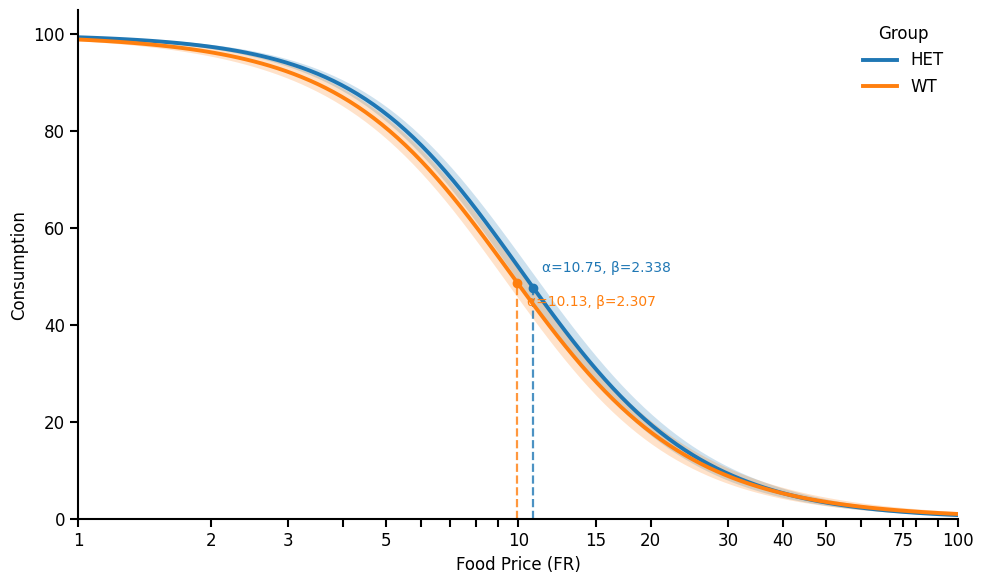

In [ ]:
# @title Grouped Demand Curves

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem
from itertools import cycle
import os

def plot_group_mean_demand_with_params(group_col='XGroup', mapping_obj_name='files_to_group_both',
                                       price_grid=None, n_grid=120, P_min=1.0, fallback_max_P=128,
                                       annotate_x_frac=0.18):

    # --- mapping ---
    mapping = None
    for name in (mapping_obj_name, 'files_to_group_both', 'files_to_group_x', 'files_to_group_hue'):
        if name in globals():
            mapping = globals()[name].copy()
            break
    if mapping is None:
        _meta = metadata_df.copy()
        _meta['filename'] = _meta['filename'].apply(lambda p: os.path.basename(str(p))) if 'filename' in _meta.columns else _meta.index.astype(str)
        mapping = pd.DataFrame({'filename': _meta['filename'], group_col: 'ALL'})

    if group_col not in mapping.columns:
        raise ValueError(f"mapping does not contain group column '{group_col}'")

    # filename -> Mouse_ID
    if 'md' in globals() and 'filename' in md.columns and 'Mouse_ID' in md.columns:
        fname_to_mouse = md.set_index('filename')['Mouse_ID'].to_dict()
    elif 'bm' in globals() and 'filename' in bm.columns and 'Mouse_ID' in bm.columns:
        fname_to_mouse = bm.set_index('filename')['Mouse_ID'].to_dict()
    else:
        raise RuntimeError("Cannot find filename -> Mouse_ID mapping (need `md` or `bm`).")

    # demand params table
    if 'bm' not in globals():
        raise RuntimeError("Need `bm` (PRmetrics_merged copy) with Demand_alpha_FR & Demand_beta_FR.")
    metrics = bm.copy()
    alpha_col = 'Demand_alpha_FR'
    beta_col  = 'Demand_beta_FR'
    if alpha_col not in metrics.columns or beta_col not in metrics.columns:
        raise RuntimeError(f"`bm` must contain '{alpha_col}' and '{beta_col}'.")

    # normalize mapping file basenames
    mapping['filename'] = mapping['filename'].astype(str).apply(lambda p: os.path.basename(str(p)))

    # choose price grid if not provided
    if price_grid is None:
        maxP_candidates = []
        max_alpha = metrics[alpha_col].dropna().max()
        if pd.notna(max_alpha):
            maxP_candidates.append(float(max_alpha) * 8.0)
        if 'demand_raw_df' in globals() and 'PricePaid' in demand_raw_df.columns:
            maxP_candidates.append(int(demand_raw_df['PricePaid'].max()))
        maxP = int(max(maxP_candidates) if maxP_candidates else fallback_max_P)
        maxP = max(maxP, P_min + 1)
        price_grid = np.unique(np.logspace(np.log10(max(P_min, 1.0)), np.log10(maxP), n_grid))
    else:
        price_grid = np.asarray(price_grid, dtype=float)

    def predict_Q(P, alpha, beta):
        P = np.asarray(P, dtype=float)
        return 100.0 / (1.0 + (P / alpha) ** beta)

    groups = mapping[group_col].dropna().unique().tolist()

    # colors from widget
    if 'group_colors' in globals() and isinstance(group_colors, dict):
        color_map = {g: group_colors.get(g, None) for g in groups}
    else:
        color_map = {g: None for g in groups}

    default_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

    # ONE figure / axes for all groups
    fig, ax = plt.subplots(figsize=(10, 6))

    stat_rows = []
    for gi, g in enumerate(groups):
        subset = mapping.loc[mapping[group_col] == g, 'filename'].unique().tolist()
        mice = [fname_to_mouse.get(os.path.basename(f), None) for f in subset]
        unique_mice = sorted({m for m in mice if pd.notna(m)})

        mice_with_params = []
        for m in unique_mice:
            row = metrics.loc[metrics['Mouse_ID'] == m]
            if row.empty:
                continue
            a = row[alpha_col].values[0]
            b = row[beta_col].values[0]
            if pd.isna(a) or pd.isna(b):
                continue
            if float(a) <= 0 or float(b) <= 0:
                continue
            mice_with_params.append((m, float(a), float(b)))

        if len(mice_with_params) == 0:
            print(f"[Group '{g}'] no mice with valid alpha/beta — skipped.")
            continue

        Qs = np.vstack([predict_Q(price_grid, a, b) for (_m,a,b) in mice_with_params])
        mean_Q = np.nanmean(Qs, axis=0)
        sem_Q  = sem(Qs, axis=0, nan_policy='omit')

        color = color_map.get(g)
        if not color:
            color = next(default_cycle)

        alphas = np.array([a for (_m,a,b) in mice_with_params])
        betas  = np.array([b for (_m,a,b) in mice_with_params])
        a_mean, a_sem = alphas.mean(), sem(alphas)
        b_mean, b_sem = betas.mean(), sem(betas)

        Q_meanparams_at_alpha = predict_Q(a_mean, a_mean, b_mean)
        ix_closest = np.argmin(np.abs(price_grid - a_mean))
        P_meancurve = price_grid[ix_closest]
        Q_meancurve = mean_Q[ix_closest]

        print(f"[{g}]")
        print(f"  alpha_mean = {a_mean:.4f}, beta_mean = {b_mean:.4f}")
        print(f"  Q_meanparams(P = alpha_mean): P = {a_mean:.4f}, Q = {Q_meanparams_at_alpha:.4f}")
        print(f"  Q_meancurve (nearest alpha_mean): P = {P_meancurve:.4f}, Q = {Q_meancurve:.4f}")
        print()

        # curve + SEM
        ax.plot(price_grid, mean_Q, label=g, color=color, linewidth=2.8)
        ax.fill_between(price_grid, mean_Q - sem_Q, mean_Q + sem_Q,
                        alpha=0.22, edgecolor='none', linewidth=0, facecolor=color)

        # marker & vertical line at alpha
        x_alpha = P_meancurve
        y_alpha = Q_meancurve
        ax.vlines(x_alpha, 0, y_alpha, linestyle='--', linewidth=1.6,
                  color=color, alpha=0.8)
        ax.plot(x_alpha, y_alpha, 'o', color=color, markersize=6)

        # text, alternating above/below
        text_x = x_alpha * 1.05
        vertical_offset = 4
        direction = 1 if gi % 2 == 0 else -1
        text_y = y_alpha + direction * vertical_offset
        text = rf"α={a_mean:.2f}, β={b_mean:.3f}"
        ax.text(text_x, text_y, text, color=color, fontsize=10,
                ha='left', va='center')

        stat_rows.append({
            'Group': g,
            'N_mice': len(mice_with_params),
            'alpha_mean': a_mean, 'alpha_sem': a_sem,
            'beta_mean': b_mean,  'beta_sem': b_sem
        })

    # axes / legend
    ax.set_xscale('log')
    ax.set_xlabel('Food Price (FR)')
    ax.set_yticks(np.arange(0, 101, 20)); ax.set_ylim(0, 105)
    ax.set_xlim(1, 100)
    ticks = np.array([1,2,3,5,10,15,20,30,40,50,75,100], float)
    ax.set_xticks(ticks); ax.set_xticklabels([str(int(x)) for x in ticks])
    ax.set_ylabel('Consumption')
    ax.set_title('')
    ax.spines['left'].set_position(('data', 1))
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(axis='both', which='both', width=1.5, length=6)

    ax.legend(title="Group", frameon=False)

    plt.tight_layout()

    stat_df = pd.DataFrame(stat_rows).sort_values('Group').reset_index(drop=True)
    if not stat_df.empty:
        display(stat_df[['Group','N_mice','alpha_mean','alpha_sem','beta_mean','beta_sem']].round(3))
    return fig, stat_df

from google.colab import files as gfiles

fig, stats = plot_group_mean_demand_with_params(group_col='XGroup')

# save
outdir = "/content"
os.makedirs(outdir, exist_ok=True)
fname = f"demand_plot_{datetime.now():%Y%m%d_%H%M%S}.pdf"
path = os.path.join(outdir, fname)
fig.savefig(path, format="pdf", dpi=300, bbox_inches="tight", transparent=True)
gfiles.download(path)

# show
plt.show()

# **Individual normalized demand curves fit with a (Q_0)-fixed log-logistic model**  
Each plot shows **normalized** pellet consumption (Q) (gray points) as a function of normalized price (*P*)for a single animal. For each animal, we normalized the raw data by setting the lowest-price consumption to 100% and rescaling both axes: (q = 100/B) where (B) is consumption at the lowest price; then (P = Price X q) and (Q = Consumption X q). This forces all curves to start at (Q=100), removing trivial level differences and enabling like-for-like comparisons of elasticity across animals.

The fitted demand curve (black line) was obtained by nonlinear least squares using a (Q_0)-fixed log-logistic model: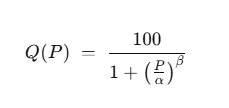

**Where**  
- alpha is the normalized price at which consumption is halved ((Q=50)),  
- beta captures the local steepness of the decline around alpha.  
**Each plot displays**:  

- Gray points: normalized observed data,  
- Black line: fitted demand curve,  
- Red dashed line and red point: alpha half-max price, (Q=50),  
- Light blue line: local slope at alpha.  
**Interpretation**
Because normalization fixes (Q_0=100), (Q_0) is no longer a free parameter and level differences are removed. Thus:  

- alpha indexes cost sensitivity on a common scale; higher alpha indicates greater willingness to pay before consumption falls to half.  
- beta quantifies how sharply consumption declines as (P) increases (larger beta → steeper drop).    

Optionally, we also report (Pmax) (vertical dotted line when included), defined as the price where elasticity equals (-1) and response output peaks.